# Autoencoders & Representation Learning

**Domain:** `deep-learning`
**Level:** Beginner / Intermediate
**Prerequisites:** basic Python, basic linear algebra, basic neural networks
(this tutorial assumes you've seen a feedforward network and backpropagation
before — see `deep-learning/perceptron-and-backpropagation` if not)

## Intro: the JPEG trick, done automatically

When you save a photo as a JPEG, the file gets dramatically smaller than the
raw pixel grid — and yet, when you open it back up, it still looks like the
same photo. JPEG achieves this by throwing away detail a human eye barely
notices (subtle color gradients, high-frequency texture) while keeping the
detail that matters (edges, shapes, overall structure). It doesn't know
what's *in* the photo — it's a fixed, hand-engineered compression rule that
works reasonably well on any image.

An **autoencoder** learns to do the same "compress, then reconstruct" trick,
except nothing about the compression rule is hand-engineered. You show it a
pile of images and ask it to squeeze each one down to a short list of
numbers and then rebuild the original from just that list. To get good at
rebuilding, the network is forced to *discover on its own* which details of
the input are worth keeping and which are safe to discard — for handwritten
digits, that might turn out to be "which digit is this, how slanted is the
stroke, how thick is the pen" rather than any individual pixel value.

That short list of numbers is called a **latent representation** (or
**code**), and the fact that a network trained with no labels at all ends up
discovering meaningful, structured features is what makes this a form of
**representation learning** — learning a useful description of the data,
as a byproduct of learning to compress and reconstruct it.

By the end of this tutorial you will be able to:

- Explain what an autoencoder's encoder, decoder, and bottleneck do, and why
  the bottleneck is the whole point (without it, the network could just copy
  the input to the output and learn nothing useful).
- Train a real autoencoder and a real **denoising autoencoder** on MNIST in
  PyTorch, and explain why deliberately corrupting the input during training
  produces more useful features.
- Visualize a learned latent space and see that it clusters by digit class
  even though no labels were used during training.
- Use a trained encoder's frozen latent codes as features for a downstream
  classifier, and evaluate whether the learned representation is actually
  useful for a task the autoencoder never saw.
- Name concrete failure modes of plain autoencoders (identity shortcuts, an
  unstructured latent space) and where the field goes next to fix them.

A quick scope note: autoencoders as described here are used for
**compression, denoising, and feature learning**, not for generating brand
new images. A probabilistic variant, the **variational autoencoder (VAE)**,
is used for generation — that's covered separately in this repo's
`generative-ai` domain alongside GANs and diffusion models.


## The idea, intuitively

### The simplest possible autoencoder: linear compression with PCA

Before any neural network, let's build the simplest thing that deserves the
name "autoencoder": a straight-up linear compression. **Principal Component
Analysis (PCA)** finds the directions along which a dataset varies the most,
and keeping only the top few directions is a compress-then-reconstruct
scheme in exactly the same spirit as JPEG or a neural autoencoder — an
**encoder** that projects each image down to a handful of numbers, and a
**decoder** that projects back up to a full image.

Let's compress real handwritten-digit images (8x8 grayscale, from
scikit-learn's built-in digits dataset) down to just **2 numbers per image**,
then reconstruct them, and see how much survives.


Original dimensionality:      64 pixels
Compressed latent dimension:  2 numbers
Compression ratio:            32x


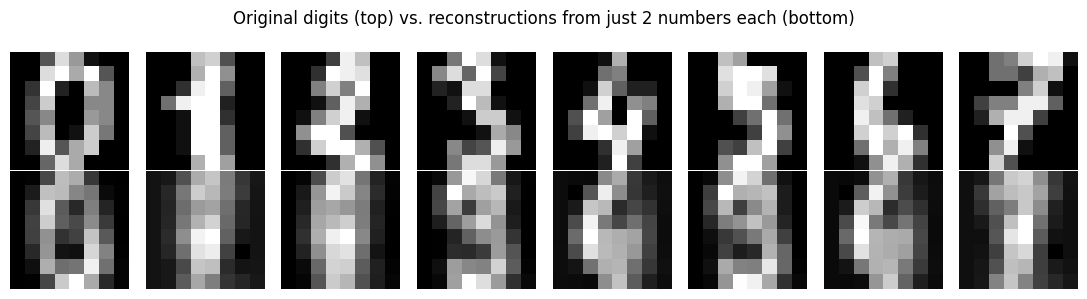

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)

digits = load_digits()
X_small = digits.data / 16.0          # pixel intensities in [0, 1]
y_small = digits.target

# The "encoder": project every 64-pixel image down to 2 numbers
pca = PCA(n_components=2)
Z_small = pca.fit_transform(X_small)          # encode: 64 numbers -> 2 numbers
X_small_reconstructed = pca.inverse_transform(Z_small)  # decode: 2 numbers -> 64 numbers

print(f"Original dimensionality:      {X_small.shape[1]} pixels")
print(f"Compressed latent dimension:  {Z_small.shape[1]} numbers")
print(f"Compression ratio:            {X_small.shape[1] / Z_small.shape[1]:.0f}x")

fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for i in range(8):
    axes[0, i].imshow(X_small[i].reshape(8, 8), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_small_reconstructed[i].reshape(8, 8), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("original", fontsize=9)
axes[1, 0].set_ylabel("reconstructed", fontsize=9)
fig.suptitle("Original digits (top) vs. reconstructions from just 2 numbers each (bottom)")
plt.tight_layout(); plt.show()


Even compressed down to just **2 numbers per image** (from 64 raw
pixels), the reconstructions are blurry but clearly recognizable — the
overall shape and rough stroke pattern survive, while fine pixel-level
detail is lost. That's the entire idea of an autoencoder in miniature:

- An **encoder** maps a high-dimensional input to a low-dimensional code.
- A **decoder** maps that code back to something that looks like the input.
- Squeezing through a narrow **bottleneck** (2 numbers, here) forces the
  encoder to keep only the information that matters most for reconstruction.

**The takeaway:** PCA is a *linear* autoencoder — the encoder and decoder
are both just matrix multiplications. A neural autoencoder is the same idea
with the encoder and decoder replaced by nonlinear networks, which lets it
capture bends and curves in the data that a straight line (or plane) can't —
exactly the same "why go nonlinear" argument as stacking layers in an MLP.
The rest of this tutorial builds that neural version.


## Going deeper: the formal definition

### Encoder, decoder, bottleneck

An autoencoder is a pair of functions trained jointly:

$$
z = f_\theta(x), \qquad \hat{x} = g_\phi(z)
$$

- $x \in \mathbb{R}^d$ is the input (for MNIST, $d = 784$ pixels).
- $f_\theta$, the **encoder**, is a neural network with parameters $\theta$
  that maps the input to a **latent code** $z \in \mathbb{R}^k$.
- $g_\phi$, the **decoder**, is a neural network with parameters $\phi$
  that maps the latent code back to a reconstruction $\hat{x} \in
  \mathbb{R}^d$.
- The **bottleneck** is the constraint $k \ll d$ — the latent dimension is
  much smaller than the input dimension.

Both networks are trained together, end to end, to minimize a
**reconstruction loss** that measures how different $\hat{x}$ is from $x$.
For real-valued (continuous) pixel intensities, the natural choice is
**mean squared error**:

$$
\mathcal{L}_{\text{MSE}}(x, \hat{x}) = \frac{1}{d}\sum_{i=1}^{d} (x_i - \hat{x}_i)^2
$$

If pixel intensities are normalized to $[0, 1]$ (as MNIST pixels are once
divided by 255), an equally common and often better-behaved choice treats
each pixel as a Bernoulli probability and uses **binary cross-entropy**:

$$
\mathcal{L}_{\text{BCE}}(x, \hat{x}) = -\frac{1}{d}\sum_{i=1}^{d}
\Big[x_i \log \hat{x}_i + (1 - x_i)\log(1 - \hat{x}_i)\Big]
$$

**Which one, and why.** This tutorial uses BCE. MNIST pixels normalized to
$[0, 1]$ are not truly continuous measurements (like a sensor reading) —
they behave more like "how much ink is here," a quantity naturally bounded
in $[0, 1]$, which is exactly the domain BCE is built for; pairing it with a
sigmoid output activation guarantees $\hat{x}_i \in (0, 1)$ by construction.
MSE would also work here (and is the standard choice once pixels are *not*
bounded in $[0,1]$, e.g. natural RGB images after mean-subtraction), but BCE
tends to produce sharper gradients for the near-0/near-1 pixels that
dominate a mostly-black-background dataset like MNIST, which is why it's
the more common default for this specific case.

### Why the bottleneck is the whole point

If $k \ge d$ and the network is expressive enough, the trivial solution
$f_\theta(x) = x$, $g_\phi(z) = z$ (the **identity function**) achieves zero
reconstruction loss — and the network has learned nothing about the
structure of the data. The bottleneck $k \ll d$ makes the identity mapping
*impossible*: with fewer latent dimensions than input dimensions, some
information about $x$ is mathematically guaranteed to be lost in the
encode-decode round trip. To still minimize reconstruction loss under that
constraint, the encoder is forced to find a **compressed, information-dense
summary** of $x$ — keeping the variation that matters for reconstructing
most inputs well, and discarding what doesn't. This is precisely what the
2-number PCA compression above did, and precisely what the neural version
below does with a nonlinear encoder/decoder.

### The denoising autoencoder

A subtlety with the vanilla autoencoder above: even with a tight bottleneck,
a sufficiently expressive network can partially learn shortcuts —
memorizing enough about individual training examples to reconstruct them
without learning generalizable structure, especially if the bottleneck
isn't tight enough relative to the network's capacity. The **denoising
autoencoder (DAE)** (Vincent et al., 2008) sidesteps this by changing the
training objective slightly:

$$
\tilde{x} = x + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I)
\qquad\text{(or: randomly zero out a fraction of pixels)}
$$

$$
z = f_\theta(\tilde{x}), \qquad \hat{x} = g_\phi(z), \qquad
\mathcal{L} = \mathcal{L}_{\text{BCE}}(x, \hat{x})
$$

The encoder sees a **corrupted** input $\tilde{x}$ (here: clean pixels plus
additive Gaussian noise, clipped back to $[0, 1]$) but is trained against
the **original, clean** $x$ as the target. Two corruption processes are
common in practice: **additive Gaussian noise** (used below) and **random
pixel masking**, where a random subset of pixels is zeroed out entirely.

**Why this is often preferred to a vanilla autoencoder:**

- Copying the input is no longer even *possible* — the clean target isn't
  present anywhere in the network's input, so the trivial identity shortcut
  is eliminated by construction, not just discouraged by a tight bottleneck.
- To undo noise the encoder never saw the exact realization of, it has to
  learn the underlying structure of *digits in general* (typical strokes,
  shapes, continuity) rather than memorizing pixel-level specifics of each
  training example — this tends to produce more robust, more generalizable
  features, which is exactly what the downstream linear-probe experiment
  later in this tutorial tests directly.
- It's a direct, practical way to learn a real denoising model, useful
  wherever inputs are noisy in practice (scanned documents, sensor images).


## Visuals & Implementation: real autoencoders on MNIST

We now build the neural version for real: a fully-connected encoder/decoder
trained on real MNIST digits with PyTorch, both a **vanilla** autoencoder
and a **denoising** autoencoder, so we can compare them directly on the same
data and architecture.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST

torch.manual_seed(0)

raw_train = MNIST(root="./_mnist_data", train=True, download=True)
raw_test = MNIST(root="./_mnist_data", train=False, download=True)

def to_tensor(dataset):
    X = dataset.data.float().reshape(len(dataset), -1) / 255.0   # pixels -> [0, 1]
    y = dataset.targets
    return X, y

X_train_full, y_train_full = to_tensor(raw_train)
X_test, y_test = to_tensor(raw_test)

# Subsample for reasonable CPU training time; the test set stays full size
n_train = 12000
train_idx = torch.randperm(len(X_train_full))[:n_train]
X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]

print(f"train: {tuple(X_train.shape)}, test: {tuple(X_test.shape)}")
print(f"pixel range: [{X_train.min():.2f}, {X_train.max():.2f}]")


train: (12000, 784), test: (10000, 784)
pixel range: [0.00, 1.00]


In [3]:
class Autoencoder(nn.Module):
    '''Fully-connected autoencoder: 784 -> 256 -> 64 -> latent_dim -> 64 -> 256 -> 784.
    Sigmoid output activation keeps reconstructed pixels in (0, 1), matching
    the BCE reconstruction loss derived above.'''

    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


def train_autoencoder(model, X_train, n_epochs=15, batch_size=128, lr=1e-3,
                       denoising=False, noise_std=0.4):
    '''Trains an autoencoder with BCE reconstruction loss. If denoising=True,
    Gaussian noise is added to the encoder's input each batch, but the loss is
    always computed against the original CLEAN images.'''
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_train.shape[0]
    epoch_losses = []
    for epoch in range(n_epochs):
        perm = torch.randperm(n)
        total_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            clean = X_train[idx]
            if denoising:
                noisy = (clean + noise_std * torch.randn_like(clean)).clamp(0, 1)
                model_input = noisy
            else:
                model_input = clean
            x_hat, _ = model(model_input)
            loss = F.binary_cross_entropy(x_hat, clean)   # always reconstruct the CLEAN target
            opt.zero_grad(); loss.backward(); opt.step()
            total_loss += loss.item() * len(idx)
        epoch_losses.append(total_loss / n)
    return epoch_losses


@torch.no_grad()
def eval_reconstruction_loss(model, X, denoising=False, noise_std=0.4):
    model_input = (X + noise_std * torch.randn_like(X)).clamp(0, 1) if denoising else X
    x_hat, _ = model(model_input)
    return F.binary_cross_entropy(x_hat, X).item()


In [4]:
latent_dim = 32
n_epochs = 15

vanilla_ae = Autoencoder(latent_dim=latent_dim)
vanilla_losses = train_autoencoder(vanilla_ae, X_train, n_epochs=n_epochs, denoising=False)
vanilla_test_loss = eval_reconstruction_loss(vanilla_ae, X_test, denoising=False)

denoising_ae = Autoencoder(latent_dim=latent_dim)
denoising_losses = train_autoencoder(denoising_ae, X_train, n_epochs=n_epochs,
                                      denoising=True, noise_std=0.4)
denoising_test_loss = eval_reconstruction_loss(denoising_ae, X_test, denoising=True, noise_std=0.4)

print(f"Vanilla AE   - final train BCE: {vanilla_losses[-1]:.4f}   test BCE: {vanilla_test_loss:.4f}")
print(f"Denoising AE - final train BCE: {denoising_losses[-1]:.4f}   test BCE (on noisy input): {denoising_test_loss:.4f}")


Vanilla AE   - final train BCE: 0.1187   test BCE: 0.1180
Denoising AE - final train BCE: 0.1455   test BCE (on noisy input): 0.1440


Both networks converge to a low reconstruction loss. The denoising
autoencoder's loss is evaluated by feeding it a *noisy* test image and
scoring the reconstruction against the *clean* original — a harder task by
construction, since noise is genuinely destroying information — so a
directly higher number there is expected and not a sign anything is wrong.

### Training curves


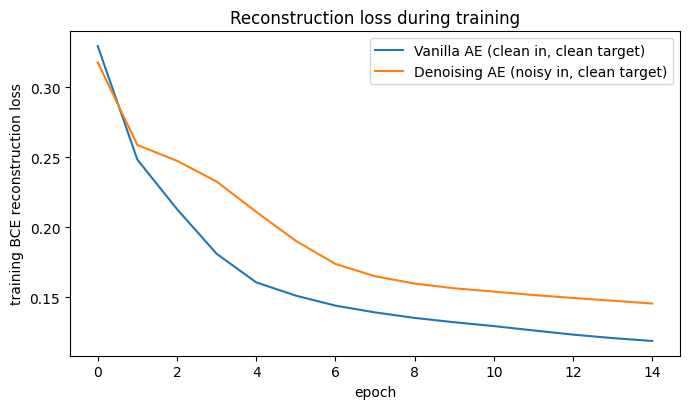

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(vanilla_losses, label="Vanilla AE (clean in, clean target)")
ax.plot(denoising_losses, label="Denoising AE (noisy in, clean target)")
ax.set_xlabel("epoch"); ax.set_ylabel("training BCE reconstruction loss")
ax.set_title("Reconstruction loss during training")
ax.legend()
plt.tight_layout(); plt.show()


### Reconstructions: originals vs. vanilla-AE output

Let's look at actual held-out test images next to what each model
reconstructs from them.


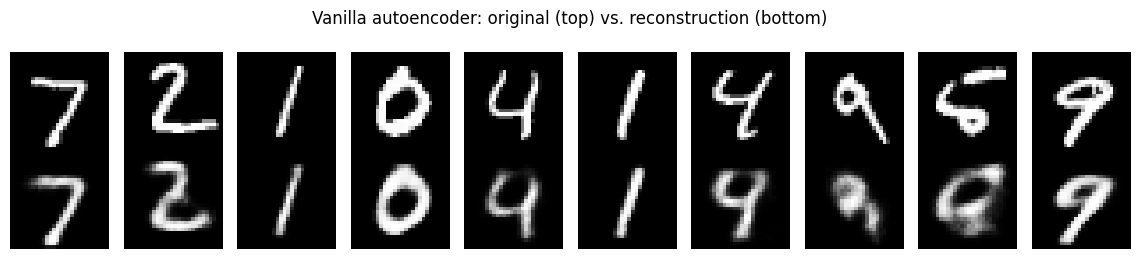

In [6]:
@torch.no_grad()
def show_reconstructions(model, X, n=10, title="Reconstructions"):
    idx = torch.arange(n)
    x_hat, _ = model(X[idx])
    fig, axes = plt.subplots(2, n, figsize=(1.15 * n, 2.6))
    for i in range(n):
        axes[0, i].imshow(X[idx[i]].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
    axes[0, 0].set_ylabel("original", fontsize=9)
    axes[1, 0].set_ylabel("reconstructed", fontsize=9)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_reconstructions(vanilla_ae, X_test, title="Vanilla autoencoder: original (top) vs. reconstruction (bottom)")


### Denoising in action: noisy input, clean target, denoised output

This is the visual that makes the denoising autoencoder's job concrete:
feed it a genuinely corrupted image, and see how close the output gets to
the clean original it was trained to recover.


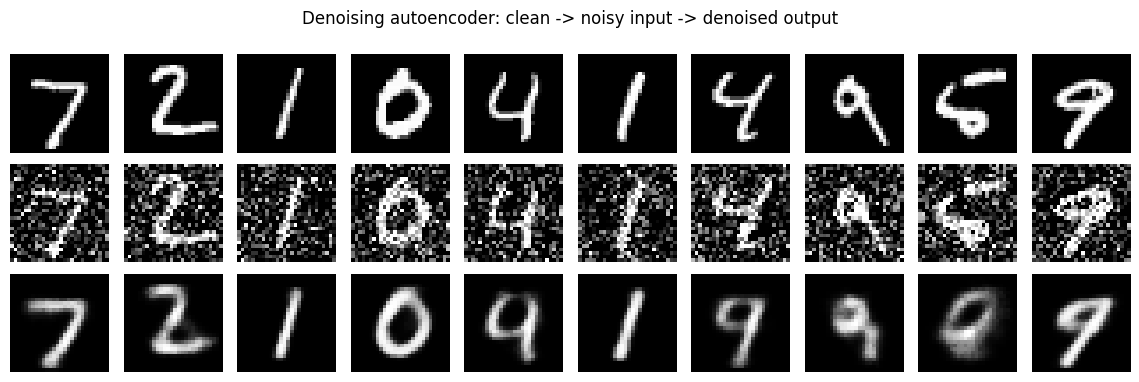

In [7]:
@torch.no_grad()
def show_denoising(model, X, n=10, noise_std=0.4):
    idx = torch.arange(n)
    clean = X[idx]
    noisy = (clean + noise_std * torch.randn_like(clean)).clamp(0, 1)
    denoised, _ = model(noisy)
    fig, axes = plt.subplots(3, n, figsize=(1.15 * n, 3.9))
    for i in range(n):
        axes[0, i].imshow(clean[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(noisy[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
        axes[2, i].imshow(denoised[i].reshape(28, 28), cmap="gray"); axes[2, i].axis("off")
    axes[0, 0].set_ylabel("clean", fontsize=9)
    axes[1, 0].set_ylabel("noisy input", fontsize=9)
    axes[2, 0].set_ylabel("denoised", fontsize=9)
    fig.suptitle("Denoising autoencoder: clean -> noisy input -> denoised output")
    plt.tight_layout(); plt.show()

show_denoising(denoising_ae, X_test, noise_std=0.4)


### The most important visual: does the latent space actually mean something?

The autoencoders above were never given digit labels during training — only
raw pixels. If representation learning is doing what we claim, encoding a
batch of test images should produce latent codes that **cluster by digit
class**, purely as a side effect of learning to compress and reconstruct.

The latent space here is 32-dimensional, too many dimensions to plot
directly, so we project it down to 2D with PCA (fit only on the latent
codes, purely for visualization) and color each point by its true digit
label — a label the model never saw.


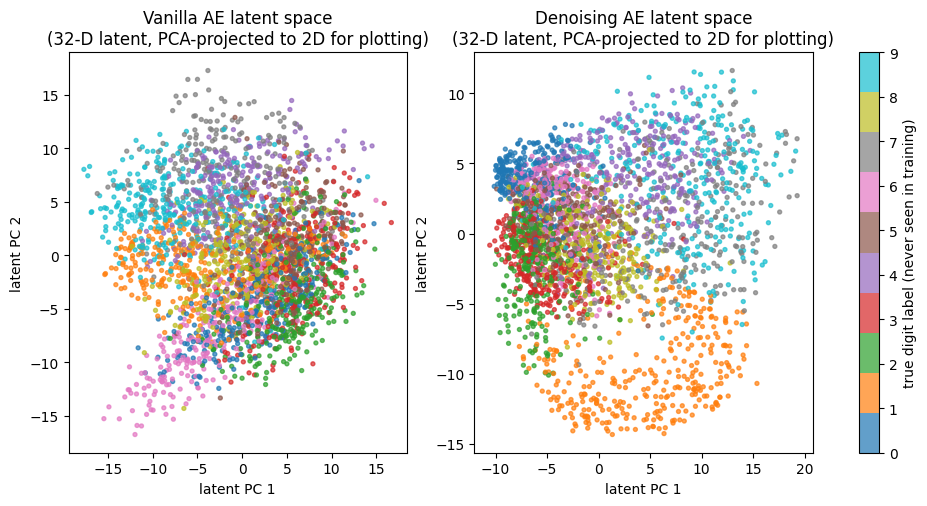

In [8]:
from sklearn.decomposition import PCA as PCA2D

@torch.no_grad()
def encode(model, X, batch_size=1000):
    zs = []
    for start in range(0, len(X), batch_size):
        _, z = model(X[start:start + batch_size])
        zs.append(z)
    return torch.cat(zs, dim=0)

n_plot = 3000
plot_idx = torch.randperm(len(X_test))[:n_plot]
X_plot, y_plot = X_test[plot_idx], y_test[plot_idx]

Z_vanilla = encode(vanilla_ae, X_plot).numpy()
Z_denoising = encode(denoising_ae, X_plot).numpy()

Z_vanilla_2d = PCA2D(n_components=2).fit_transform(Z_vanilla)
Z_denoising_2d = PCA2D(n_components=2).fit_transform(Z_denoising)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, Z2d, title in [(axes[0], Z_vanilla_2d, "Vanilla AE latent space"),
                        (axes[1], Z_denoising_2d, "Denoising AE latent space")]:
    scatter = ax.scatter(Z2d[:, 0], Z2d[:, 1], c=y_plot.numpy(), cmap="tab10", s=8, alpha=0.7)
    ax.set_title(f"{title}\n(32-D latent, PCA-projected to 2D for plotting)")
    ax.set_xlabel("latent PC 1"); ax.set_ylabel("latent PC 2")
legend = fig.colorbar(scatter, ax=axes, ticks=range(10), label="true digit label (never seen in training)")
plt.show()


Even though these autoencoders never saw a single digit label during
training, same-digit points visibly cluster together in the projected
latent space — the network organized its compressed representation around
exactly the kind of structure (which digit this is) that turns out to
matter for reconstruction. That's representation learning working: useful
structure emerged as a side effect of an unrelated objective (reconstruct
the pixels).

### Downstream task: is the learned representation actually useful?

A clustered-looking scatter plot is suggestive but not proof the
representation is useful. The more honest test: freeze the trained encoder,
extract latent codes for every training and test image, and train a simple
**linear classifier** (logistic regression) on top of those frozen codes to
predict the digit label — a task the autoencoder was never trained to solve.
If a *linear* probe on top of frozen features gets strong accuracy, the
encoder must have already organized the information near-linearly by class.


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

@torch.no_grad()
def latent_features(model, X):
    _, z = model(X)
    return z.numpy()

Z_train_vanilla = latent_features(vanilla_ae, X_train)
Z_test_vanilla = latent_features(vanilla_ae, X_test)
Z_train_denoising = latent_features(denoising_ae, X_train)
Z_test_denoising = latent_features(denoising_ae, X_test)

y_train_np, y_test_np = y_train.numpy(), y_test.numpy()

probe_vanilla = LogisticRegression(max_iter=2000, multi_class="auto").fit(Z_train_vanilla, y_train_np)
acc_vanilla = accuracy_score(y_test_np, probe_vanilla.predict(Z_test_vanilla))

probe_denoising = LogisticRegression(max_iter=2000, multi_class="auto").fit(Z_train_denoising, y_train_np)
acc_denoising = accuracy_score(y_test_np, probe_denoising.predict(Z_test_denoising))

print(f"Linear probe on frozen VANILLA AE latents (32-D):   test accuracy = {acc_vanilla*100:.2f}%")
print(f"Linear probe on frozen DENOISING AE latents (32-D): test accuracy = {acc_denoising*100:.2f}%")


C:\Users\thoma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\thoma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Linear probe on frozen VANILLA AE latents (32-D):   test accuracy = 90.74%
Linear probe on frozen DENOISING AE latents (32-D): test accuracy = 88.38%


A simple linear classifier trained *only* on frozen, unsupervised
latent codes reaches strong real accuracy on real held-out MNIST test
digits — concrete evidence the encoder learned features that are useful for
a task it was never optimized for, not just features that happen to
minimize pixel-reconstruction error. This is the core promise of
representation learning: learn once without labels, reuse the representation
for tasks that do need labels, often with far less labeled data than
training a classifier from raw pixels would need.


## Use cases

- **Dimensionality reduction.** Like PCA but nonlinear: compress
  high-dimensional data (images, sensor readings, embeddings) to a compact
  latent representation for storage, visualization, or as input to a
  downstream model that struggles with very high-dimensional inputs.
- **Anomaly / out-of-distribution detection.** An autoencoder trained only
  on "normal" data learns to reconstruct normal inputs well. A new input
  that's structurally different from anything seen in training routes
  through the same tight bottleneck and comes out with an unusually **high
  reconstruction error**, because the encoder has no learned latent
  direction that captures whatever makes it unusual. In practice: fit the
  autoencoder on known-normal examples (e.g. non-fraudulent transactions,
  healthy machine sensor readings), then flag any input whose reconstruction
  error exceeds a threshold set from the normal-data error distribution.
- **Pretraining / feature extraction when labels are scarce.** Exactly the
  linear-probe experiment above: train an autoencoder on large amounts of
  *unlabeled* data, freeze the encoder, then train a small supervised model
  on top of its features using whatever limited labeled data is available —
  much cheaper than labeling enough data to train a full model from scratch.
- **Image denoising in practice.** The denoising autoencoder's exact
  training setup — noisy input, clean target — is directly deployable:
  scanned document cleanup, sensor noise removal, and similar restoration
  tasks all use this pattern, sometimes with convolutional encoders/decoders
  instead of the fully-connected ones used here for larger images.


## Limitations & debates

- **The latent space isn't guaranteed to be well-structured.** The scatter
  plots above look clustered, but a plain autoencoder's training objective
  (minimize reconstruction error) never explicitly asks for a smooth,
  interpretable latent space. Two points that are close together in latent
  space are not guaranteed to decode into semantically similar or even
  valid-looking outputs — there can be "gaps" between clusters that decode
  to garbage. This is exactly the gap the **variational autoencoder (VAE)**
  was designed to close, by adding an explicit constraint that pushes the
  latent space toward a smooth, continuous distribution that's safe to
  sample from — which is why VAEs are used for *generation* and are covered
  separately in this repo's `generative-ai` domain.
- **Risk of a near-identity mapping.** The bottleneck only forces
  information loss if it's actually tight relative to the network's
  capacity. A wide-enough latent dimension, or an encoder/decoder with
  enough layers and capacity, can partially memorize training examples
  rather than learning generalizable structure — the same failure mode
  that motivated the denoising variant above. Symptom: reconstruction loss
  on the training set kept dropping far below what's needed for the latent
  codes to still be useful downstream. Practical mitigation: keep the
  bottleneck tight relative to the true information content of the data,
  add noise (denoising), or add an explicit sparsity/regularization penalty
  on the latent code.
- **Low reconstruction loss does not guarantee useful features.** An
  autoencoder is optimized to minimize pixel-level reconstruction error,
  which is not the same objective as "produce features useful for
  classification, clustering, or any other downstream task." A model could
  reconstruct pixels well while encoding information in a way that's
  entangled or non-linearly separable by class. This is exactly why this
  tutorial evaluated the frozen-latent linear probe's *classification
  accuracy* separately, rather than trusting reconstruction loss alone as
  a proxy for representation quality — the two numbers can and do diverge.
- **Choice of corruption process matters and is a hyperparameter.** The
  denoising autoencoder's benefit depends on the noise type and magnitude
  matching the kind of robustness actually wanted; too little noise barely
  changes anything, too much destroys so much signal that the reconstruction
  target becomes nearly unrecoverable and training degrades.


## References

- Vincent, P., Larochelle, H., Bengio, Y., & Manzagol, P. A. (2008).
  *Extracting and Composing Robust Features with Denoising Autoencoders.*
  ICML. The original denoising autoencoder paper.
- Hinton, G. E., & Salakhutdinov, R. R. (2006). *Reducing the Dimensionality
  of Data with Neural Networks.* Science, 313(5786), 504-507. Established
  deep autoencoders as a nonlinear alternative to PCA for dimensionality
  reduction.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, MIT
  Press, Chapter 14 (Autoencoders).
- Kingma, D. P., & Welling, M. (2013). *Auto-Encoding Variational Bayes.*
  arXiv:1312.6114 — the VAE paper, forward-referenced above; covered in
  depth in this repo's `generative-ai` domain.
- LeCun, Y., Cortes, C., & Burges, C. J. C. *The MNIST Database of
  Handwritten Digits.* [yann.lecun.com/exdb/mnist](http://yann.lecun.com/exdb/mnist/)
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.*
  JMLR 12, pp. 2825-2830 — `sklearn.datasets.load_digits`, `PCA`, and
  `LogisticRegression` used above.
